In [1]:
import pandas as pd

# Read the options data file
options_data = pd.read_excel('spx_options_data.xlsx')

# Split data into calls and puts
call_options = options_data[options_data['Type'] == 'Call']
put_options = options_data[options_data['Type'] == 'Put']

# Print the first and last few rows of each dataset


print("\nFirst few rows of Put options:")
print(put_options.head())
print("\nLast few rows of Put options:")
print(put_options.tail())

print("\nFirst few rows of Call options:")
print(call_options.head())
print("\nLast few rows of Call options:")
print(call_options.tail())


# Set the current index price
current_index_price = call_options['Strike'].iloc[0]/(1-call_options['Moneyness'].iloc[0])

# Update the moneyness for calls and puts to K/S
call_options['Moneyness'] = call_options['Strike'] / current_index_price
put_options['Moneyness'] = put_options['Strike'] / current_index_price



First few rows of Put options:
    Strike  Moneyness   Bid   Mid   Ask  Volume  Open Int    Delta      IV  \
86    2600    -0.5703  0.00  0.13  0.25       0         0 -0.00030  0.8661   
87    2800    -0.5373  0.00  0.15  0.30       0         0 -0.00038  0.8045   
88    3000    -0.5042  0.05  0.20  0.35       0         0 -0.00053  0.7527   
89    3200    -0.4712  0.05  0.23  0.40       0         0 -0.00064  0.6939   
90    3400    -0.4381  0.15  0.33  0.50       0        94 -0.00096  0.6515   

   Type  
86  Put  
87  Put  
88  Put  
89  Put  
90  Put  

Last few rows of Put options:
     Strike  Moneyness     Bid      Mid     Ask  Volume  Open Int  Delta   IV  \
167    7000     0.1568   907.6   917.55   927.5       2         0    0.0  0.0   
168    7200     0.1898  1106.6  1116.70  1126.8       0         0    0.0  0.0   
169    7400     0.2229  1305.6  1315.80  1326.0       0         0    0.0  0.0   
170    7600     0.2559  1504.6  1515.45  1526.3       0         0    0.0  0.0   
171

/var/folders/wk/l91h38n17q9g2sxscxvjlmmm0000gn/T/ipykernel_57024/2450037853.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  call_options['Moneyness'] = call_options['Strike'] / current_index_price
/var/folders/wk/l91h38n17q9g2sxscxvjlmmm0000gn/T/ipykernel_57024/2450037853.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  put_options['Moneyness'] = put_options['Strike'] / current_index_price


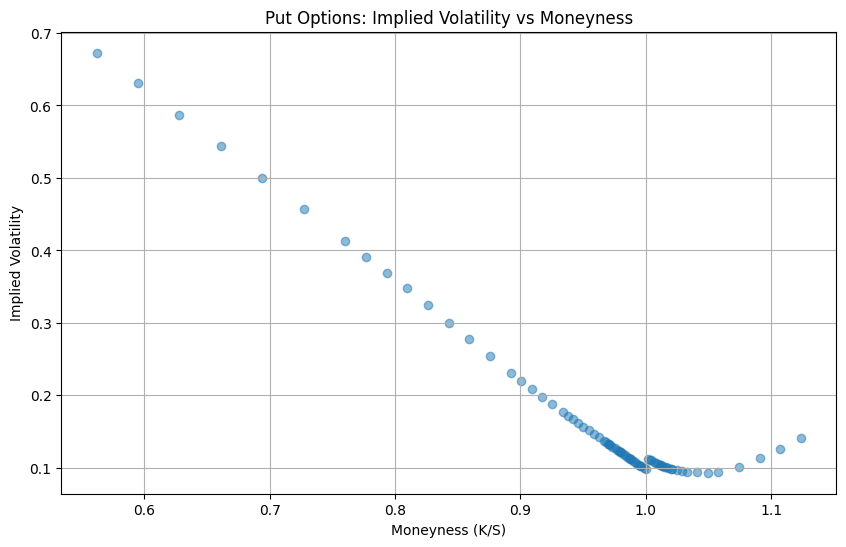

In [2]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

def black_scholes(S, K, T, r, q, sigma, option_type='Call'):
    """
    Calculate Black-Scholes option price
    S: spot price
    K: strike price
    T: time to maturity (in years)
    r: risk-free rate
    sigma: volatility
    option_type: 'Call' or 'Put'
    """
    d1 = (np.log(S/K) + (r-q + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    if option_type.lower() == 'Call':
        price = S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)
    
    return price

def implied_vol_bisection(S, K, T, r, q, market_price, option_type='Call', tolerance=1e-5, max_iter=1000):
    """
    Calculate implied volatility using bisection method
    """
    # Set initial bounds for volatility
    sigma_low = 0.0001
    sigma_high = 5.0
    
    for i in range(max_iter):
        sigma_mid = (sigma_low + sigma_high) / 2
        price = black_scholes(S, K, T, r, q, sigma_mid, option_type)
        
        if abs(price - market_price) < tolerance:
            return sigma_mid
        
        if price > market_price:
            sigma_high = sigma_mid
        else:
            sigma_low = sigma_mid
    
    return sigma_mid

# Set parameters
T = 30/365  # Assuming 30 days to maturity
r = 0.0431    # Using the 3-month T-bill rate
q = 0.01213 # The dividend yield of the S&P 500 index


# Filter OTM call options
otm_calls = call_options[call_options['Strike'] > current_index_price].copy()

# Calculate synthetic put prices using put-call parity
# P = C - S + K*exp(-rT)
otm_calls['Synthetic_Put_Bid'] = (otm_calls['Bid'] - current_index_price * np.exp(-q * T) + 
                                 otm_calls['Strike'] * np.exp(-r * T))
otm_calls['Synthetic_Put_Ask'] = (otm_calls['Ask'] - current_index_price * np.exp(-q * T) + 
                                 otm_calls['Strike'] * np.exp(-r * T))
otm_calls['Synthetic_Put_Mid'] = (otm_calls['Mid'] - current_index_price * np.exp(-q * T) + 
                                 otm_calls['Strike'] * np.exp(-r * T))
otm_calls['Delta'] = otm_calls['Delta'] - np.exp(-q * T)
otm_calls['Type'] = 'Put'

# Create DataFrame with synthetic put prices
synthetic_puts = otm_calls[['Strike', 'Moneyness', 'Synthetic_Put_Bid', 
                           'Synthetic_Put_Ask', 'Synthetic_Put_Mid', 'Type', 'Volume', 'Delta', 'Open Int', 'IV']]
synthetic_puts = synthetic_puts.rename(columns={
    'Synthetic_Put_Bid': 'Bid',
    'Synthetic_Put_Ask': 'Ask',
    'Synthetic_Put_Mid': 'Mid'
})

# Concatenate real put options with synthetic put options
put_options_data = pd.concat([put_options[put_options['Strike'] <= current_index_price], synthetic_puts], ignore_index=True)
put_options_data = put_options_data.sort_values('Strike')


# Filter out options with zero open interest or volume
put_options_data = put_options_data[(put_options_data['Open Int'] > 0) | (put_options_data['Volume'] > 0)]


# Calculate IV for put options
put_options_data['IV_calculated'] = put_options_data.apply(
    lambda row: implied_vol_bisection(
        current_index_price, 
        row['Strike'], 
        T, 
        r, 
        q,
        row['Mid'], 
        'Put'
    ) if row['Mid'] > 0 else np.nan, 
    axis=1
)

# Save the put options data to a CSV file
put_options_data.to_excel('put_options_with_IV.xlsx', index=False)

# Create scatter plot of IV vs Moneyness for put options
plt.figure(figsize=(10, 6))
plt.scatter(put_options_data['Moneyness'], put_options_data['IV_calculated'], alpha=0.5)
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.title('Put Options: Implied Volatility vs Moneyness')
plt.grid(True)

# Save the plot to PDF
plt.savefig('put_options_iv_curve_q.pdf')

plt.show()
